In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import pickle

In [3]:
with open("data/processed_data/wafer_data_caleb_fit.pkl", "rb") as f:
    wafer_data = pickle.load(f)

with open("data/processed_data/wafer_fit_results_caleb_fit.pkl", "rb") as f:
    wafer_fit_results = pickle.load(f)

with open("data/processed_data/wafer_fit_summary_caleb_fit.pkl", "rb") as f:
    wafer_fit_summary = pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed_data/wafer_data_caleb_fit.pkl'

In [13]:
def invQ_const_model(T_mK, log10_invQ0):
    return 10.0**log10_invQ0 * np.ones_like(T_mK, dtype=float)
def invQ_activation_model(T_mK, log10_invQ0, log10_Aact, Tact_K):
    return (
        10.0**log10_invQ0
        + 10.0**log10_Aact * activated_shape(T_mK, Tact_K)
    )
def activated_shape(T_mK, Tact_K):
    T_K = np.asarray(T_mK, dtype=float) * 1e-3
    return np.exp(-Tact_K / np.maximum(T_K, 1e-12))

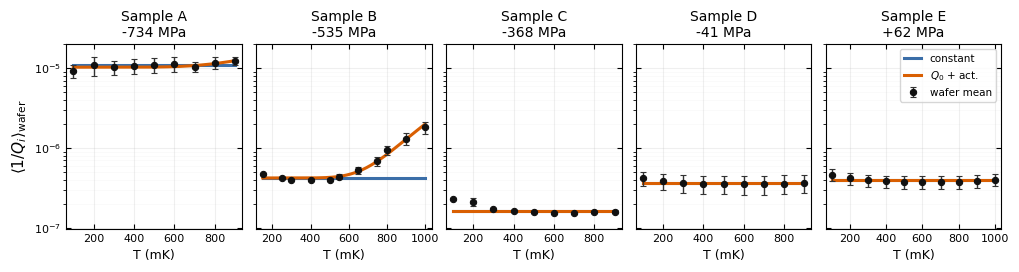

In [14]:


def plot_wafer_activation_fits_paper(
    wafer_data,
    fit_results,
    sample_order=None,
    figsize=(10, 5*.66),
    savepath=None,
):
    if sample_order is None:
        sample_order = sorted(
            fit_results.keys(),
            key=lambda s: wafer_data[s]["stress"]
        )

    # More polished, colorblind-friendly-ish palette
    color_const = "#3B6EA8"   # muted blue
    color_act   = "#D95F02"   # burnt orange
    color_data  = "#111111"
    color_err   = "#333333"

    n = len(sample_order)

    fig, axs = plt.subplots(
        1, n,
        figsize=figsize,
        sharey=True,
        constrained_layout=False,
    )

    if n == 1:
        axs = [axs]

    # Common y-limits
    all_y = []
    all_yerr = []
    for sample in sample_order:
        fit = fit_results[sample]
        all_y.extend(fit["y"])
        all_yerr.extend(fit["yerr"])

    all_y = np.asarray(all_y, dtype=float)
    all_yerr = np.asarray(all_yerr, dtype=float)

    ymin = np.nanmin(all_y - all_yerr)
    ymax = np.nanmax(all_y + all_yerr)
    ymin = max(ymin * 0.65, 1e-9)
    ymax = ymax * 1.45

    for i, sample in enumerate(sample_order):
        ax = axs[i]
        fit = fit_results[sample]
        d = wafer_data[sample]

        T = np.asarray(fit["T"], dtype=float)
        y = np.asarray(fit["y"], dtype=float)
        yerr = np.asarray(fit["yerr"], dtype=float)

        Tplot = np.linspace(np.nanmin(T), np.nanmax(T), 600)

        y_const = invQ_const_model(Tplot, *fit["constant"]["popt"])
        y_act = invQ_activation_model(Tplot, *fit["activation"]["popt"])

        # Data
        ax.errorbar(
            T, y, yerr=yerr,
            fmt="o",
            ms=4.5,
            color=color_data,
            ecolor=color_err,
            elinewidth=1.0,
            capsize=2.5,
            markeredgewidth=0.8,
            label="wafer mean",
            zorder=5,
        )

        # Constant model
        ax.plot(
            Tplot, y_const,
            lw=2.2,
            color=color_const,
            label="constant",
            zorder=3,
        )

        # Activated model
        ax.plot(
            Tplot, y_act,
            lw=2.2,
            color=color_act,
            label=r"$Q_0$ + act.",
            zorder=4,
        )

        ax.set_title(
            f"{sample}\n{d['stress']:+.0f} MPa",
            fontsize=10,
            pad=5,
        )

        ax.set_yscale("log")
        ax.set_ylim(ymin, ymax)
        ax.set_xlim(np.nanmin(T) - 35, np.nanmax(T) + 35)

        ax.grid(True, which="major", alpha=0.20, lw=0.8)
        ax.grid(True, which="minor", alpha=0.08, lw=0.5)

        ax.tick_params(axis="both", labelsize=8, direction="in", top=True, right=True)

        ax.set_xlabel("T (mK)", fontsize=9)

        if i == 0:
            ax.set_ylabel(r"$\langle 1/Q_i \rangle_{\rm wafer}$", fontsize=11)
        else:
            ax.tick_params(labelleft=False)

        # Only show legend once
        if i == n - 1:
            ax.legend(
                fontsize=7.5,
                frameon=True,
                loc="best",
                handlelength=1.7,
                borderpad=0.4,
            )

    # fig.suptitle(
    #     r"Wafer-averaged loss: constant background vs activated excess",
    #     y=0.98,
    #     fontsize=13,
    # )

    fig.subplots_adjust(
        left=0.06,
        right=0.995,
        bottom=0.22,
        top=0.78,
        wspace=0.08,
    )

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

        if savepath.lower().endswith(".png"):
            fig.savefig(savepath[:-4] + ".pdf", bbox_inches="tight")
        elif savepath.lower().endswith(".pdf"):
            fig.savefig(savepath[:-4] + ".png", dpi=300, bbox_inches="tight")

    return fig


fig = plot_wafer_activation_fits_paper(
    wafer_data,
    wafer_fit_results,
    #savepath="wafer_activation_fits_paper.png",
)
plt.show()

/var/folders/47/4fncnhqn5wq1khr62czfdv4h0000gp/T/ipykernel_98221/2955706067.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


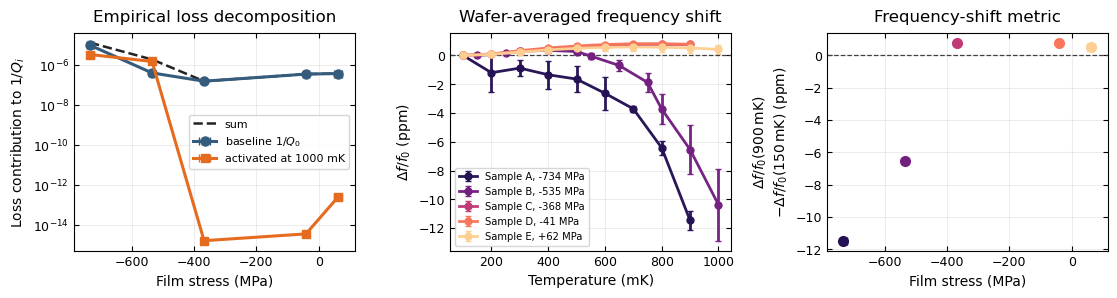

In [16]:


def plot_loss_decomposition_and_freq_shift_3panel(
    wafer_fit_summary,
    wafer_data,
    T_eval=1000.0,
    T_low=150.0,
    T_high=900.0,
    figsize=(11.0, 5*.66),
    cmap_name="magma",
    savepath=None,
):
    color_baseline = "#355C7D"
    color_act = "#E56B1F"
    color_total = "#222222"

    cmap = cm.get_cmap(cmap_name)

    # -------------------------------------------------
    # Loss decomposition
    # -------------------------------------------------
    df = wafer_fit_summary.copy().sort_values("stress")

    stress = df["stress"].to_numpy(dtype=float)
    stress_err = (
        df["stress_err"].to_numpy(dtype=float)
        if "stress_err" in df.columns
        else None
    )

    baseline_loss = 1.0 / df["Q0"].to_numpy(dtype=float)
    Aact = df["Aact"].to_numpy(dtype=float)
    Tact = df["Tact_K"].to_numpy(dtype=float)

    act_loss = Aact * np.exp(-Tact / (T_eval / 1000.0))
    total_loss = baseline_loss + act_loss

    # -------------------------------------------------
    # Figure
    # -------------------------------------------------
    fig, axs = plt.subplots(1, 3, figsize=figsize, constrained_layout=False)
    ax0, ax1, ax2 = axs

    # =================================================
    # Panel 1: loss decomposition
    # =================================================
    ax0.errorbar(
        stress,
        baseline_loss,
        xerr=stress_err,
        fmt="o-",
        lw=2.2,
        ms=6.5,
        capsize=3,
        color=color_baseline,
        label=r"baseline $1/Q_0$",
        zorder=4,
    )

    ax0.errorbar(
        stress,
        act_loss,
        xerr=stress_err,
        fmt="s-",
        lw=2.2,
        ms=6.0,
        capsize=3,
        color=color_act,
        label=fr"activated at {T_eval:.0f} mK",
        zorder=5,
    )

    ax0.plot(
        stress,
        total_loss,
        "--",
        lw=1.8,
        color=color_total,
        label="sum",
        zorder=3,
    )

    ax0.set_yscale("log")
    ax0.set_xlabel("Film stress (MPa)")
    ax0.set_ylabel(r"Loss contribution to $1/Q_i$")
    ax0.set_title("Empirical loss decomposition", fontsize=12, pad=8)
    ax0.grid(True, which="major", alpha=0.22)
    ax0.grid(True, which="minor", alpha=0.07)
    ax0.legend(fontsize=8, frameon=True, loc="best", handlelength=2.0)

    # =================================================
    # Panel 2: frequency shift curves
    # =================================================
    freq_items = sorted(
        [
            (sample, d)
            for sample, d in wafer_data.items()
            if ("mean_dff" in d) and ("std_dff" in d)
        ],
        key=lambda item: item[1]["stress"],
    )

    colors = cmap(np.linspace(0.15, 0.90, len(freq_items)))

    for color, (sample, d) in zip(colors, freq_items):
        T = np.asarray(d["T_mK"], dtype=float)
        y = np.asarray(d["mean_dff"], dtype=float)
        e = np.asarray(d["std_dff"], dtype=float)

        good = np.isfinite(T) & np.isfinite(y) & np.isfinite(e)

        if np.sum(good) == 0:
            continue

        ax1.errorbar(
            T[good],
            1e6 * y[good],
            yerr=1e6 * e[good],
            fmt="o-",
            lw=2.0,
            ms=5.0,
            capsize=2.5,
            color=color,
            alpha=0.98,
            label=f"{sample}, {d['stress']:+.0f} MPa",
        )

    ax1.axhline(0, linestyle="--", color="0.25", lw=0.9)
    ax1.set_xlabel("Temperature (mK)")
    ax1.set_ylabel(r"$\Delta f/f_0$ (ppm)")
    ax1.set_title("Wafer-averaged frequency shift", fontsize=12, pad=8)
    ax1.grid(True, which="major", alpha=0.22)
    ax1.legend(fontsize=7.2, frameon=True, loc="best", handlelength=1.8)

    # =================================================
    # Panel 3: frequency-shift metric vs stress
    # =================================================
    metric_rows = []

    for sample, d in freq_items:
        T = np.asarray(d["T_mK"], dtype=float)
        y = np.asarray(d["mean_dff"], dtype=float)

        good = np.isfinite(T) & np.isfinite(y)
        T = T[good]
        y = y[good]

        if len(T) == 0:
            continue

        i_low = np.argmin(np.abs(T - T_low))
        i_high = np.argmin(np.abs(T - T_high))

        metric_rows.append({
            "sample": sample,
            "stress": d["stress"],
            "stress_err": d.get("stress_err", np.nan),
            "delta_dff": y[i_high] - y[i_low],
            "T_low_actual": T[i_low],
            "T_high_actual": T[i_high],
        })

    metric_df = pd.DataFrame(metric_rows).sort_values("stress")

    metric_colors = cmap(np.linspace(0.15, 0.90, len(metric_df)))

    for color, (_, row) in zip(metric_colors, metric_df.iterrows()):
        ax2.errorbar(
            row["stress"],
            1e6 * row["delta_dff"],
            xerr=row["stress_err"],
            fmt="o",
            ms=7,
            capsize=3,
            color=color,
            ecolor=color,
            elinewidth=1.2,
            zorder=4,
        )

    ax2.axhline(0, linestyle="--", color="0.25", lw=0.9)
    ax2.set_xlabel("Film stress (MPa)")
    ax2.set_ylabel(
        rf"$\Delta f/f_0({T_high:.0f}\,\mathrm{{mK}})$"
        "\n"
        rf"$-\Delta f/f_0({T_low:.0f}\,\mathrm{{mK}})$ (ppm)"
    )
    ax2.set_title("Frequency-shift metric", fontsize=12, pad=8)
    ax2.grid(True, which="major", alpha=0.22)

    # =================================================
    # Shared styling
    # =================================================
    for ax in axs:
        ax.tick_params(
            axis="both",
            labelsize=9,
            direction="in",
            top=True,
            right=True,
        )

    fig.subplots_adjust(
        left=0.055,
        right=0.995,
        bottom=0.20,
        top=0.86,
        wspace=0.34,
    )

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

        if savepath.lower().endswith(".png"):
            fig.savefig(savepath[:-4] + ".pdf", bbox_inches="tight")
        elif savepath.lower().endswith(".pdf"):
            fig.savefig(savepath[:-4] + ".png", dpi=300, bbox_inches="tight")

    return fig, metric_df


fig, freq_metric_df = plot_loss_decomposition_and_freq_shift_3panel(
    wafer_fit_summary,
    wafer_data,
    T_eval=1000.0,
    T_low=150.0,
    T_high=900.0,
    cmap_name="magma",
    #savepath="loss_decomposition_frequency_shift_3panel.png",
)

plt.show()
